# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [ ]:
STUDENT_NAME = "MAI GIA BAO"  # TODO: Họ và tên
STUDENT_ID = "24520163"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\Khoa_He_AI\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [26]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [27]:
# TODO N1
# shifted_logits = ...
# exp_logits = ...
# class_probabilities = ...
# predicted_classes = ...
# confidence_scores = ...

# tru gia tri lon nhat tren moi hang truoc khi mu hoa de tranh tran so
shifted_logits = logits - logits.max(axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / exp_logits.sum(axis=1, keepdims=True)
predicted_classes = class_probabilities.argmax(axis=1)
confidence_scores = class_probabilities.max(axis=1)

# in ra cac bien dau ra bat buoc
print("shifted_logits:")
print(shifted_logits)
print("class_probabilities:")
print(class_probabilities)
print("predicted_classes:", predicted_classes)
print("confidence_scores:", confidence_scores)

shifted_logits:
[[ 0.  -1.  -1.9]
 [-1.   0.  -2. ]
 [-5.  -4.   0. ]
 [ 0.   0.   0. ]]
class_probabilities:
[[0.65900114 0.24243297 0.09856589]
 [0.24472847 0.66524096 0.09003057]
 [0.00657326 0.01786798 0.97555875]
 [0.33333333 0.33333333 0.33333333]]
predicted_classes: [0 1 2 0]
confidence_scores: [0.65900114 0.66524096 0.97555875 0.33333333]


In [28]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [29]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [30]:
# TODO N2
# train_feature_mean = ...
# train_feature_std = ...
# X_train_scaled = ...
# X_val_scaled = ...

# chi tinh mean va std tu X_train de khong ro ri thong tin sang validation
train_feature_mean = X_train.mean(axis=0)
train_feature_std = X_train.std(axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
# validation dung lai dung mean va std cua train
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

# in ra cac bien dau ra bat buoc
print("train_feature_mean:", train_feature_mean)
print("train_feature_std:", train_feature_std)
print("X_train_scaled:")
print(X_train_scaled)
print("X_val_scaled:")
print(X_val_scaled)

train_feature_mean: [172.5         69.16666667   1.65        28.16666667]
train_feature_std: [ 7.47774476 13.04372987  0.79109629  7.64671316]
X_train_scaled:
[[-0.3343254  -0.31943828 -0.56883088 -0.80644671]
 [ 1.0029762   0.83053953  0.94805147  0.89363014]
 [-1.671627   -1.4694161  -1.07445834 -1.19877214]
 [ 0.3343254   0.06388766 -0.18961029 -0.02179586]
 [-0.60178572 -0.70276422 -0.82164461 -0.54489643]
 [ 1.27043652  1.59719141  1.70649265  1.67828099]]
X_val_scaled:
[[-0.06686508 -0.08944272 -0.31601716 -0.28334614]
 [ 2.34027779  1.98051735  2.21212011  2.20138156]]


In [31]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [32]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [33]:
# TODO N3
# correct_mask = ...
# high_confidence_mask = ...
# review_mask = ...
# review_indices = ...

# du doan dung khi class du doan trung voi nhan that
correct_mask = predicted_classes == true_labels
# confidence cao khi lon hon hoac bang nguong 0.70
high_confidence_mask = confidence_scores >= confidence_threshold
# can review neu du doan sai HOAC confidence thap
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indices = np.where(review_mask)[0]

# in ra cac bien dau ra bat buoc
print("correct_mask:", correct_mask)
print("high_confidence_mask:", high_confidence_mask)
print("review_mask:", review_mask)
print("review_indices:", review_indices)

correct_mask: [ True False  True False]
high_confidence_mask: [False False  True False]
review_mask: [ True  True False  True]
review_indices: [0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [34]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [35]:
# TODO N4
# normalized_batch = ...
# augmented_batch = ...
# augmented_batch[0, 0, 0, 0] = ...

# chuyen batch ve float32 trong doan [0, 1]
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
# flip ngang theo chieu W (axis=2), dung copy de co bo nho doc lap
augmented_batch = np.flip(normalized_batch, axis=2).copy()
augmented_batch[0, 0, 0, 0] = 1.0

# in ra cac bien dau ra bat buoc
print("normalized_batch shape:", normalized_batch.shape, "dtype:", normalized_batch.dtype)
print("augmented_batch shape:", augmented_batch.shape, "dtype:", augmented_batch.dtype)
print("normalized_batch:")
print(normalized_batch)
print("augmented_batch:")
print(augmented_batch)
print("Hai batch dung bo nho doc lap:", not np.shares_memory(normalized_batch, augmented_batch))

normalized_batch shape: (2, 4, 4, 3) dtype: float32
augmented_batch shape: (2, 4, 4, 3) dtype: float32
normalized_batch:
[[[[0.         0.00392157 0.00784314]
   [0.01176471 0.01568628 0.01960784]
   [0.02352941 0.02745098 0.03137255]
   [0.03529412 0.03921569 0.04313726]]

  [[0.04705882 0.05098039 0.05490196]
   [0.05882353 0.0627451  0.06666667]
   [0.07058824 0.07450981 0.07843138]
   [0.08235294 0.08627451 0.09019608]]

  [[0.09411765 0.09803922 0.10196079]
   [0.10588235 0.10980392 0.11372549]
   [0.11764706 0.12156863 0.1254902 ]
   [0.12941177 0.13333334 0.13725491]]

  [[0.14117648 0.14509805 0.14901961]
   [0.15294118 0.15686275 0.16078432]
   [0.16470589 0.16862746 0.17254902]
   [0.1764706  0.18039216 0.18431373]]]


 [[[0.1882353  0.19215687 0.19607843]
   [0.2        0.20392157 0.20784314]
   [0.21176471 0.21568628 0.21960784]
   [0.22352941 0.22745098 0.23137255]]

  [[0.23529412 0.23921569 0.24313726]
   [0.24705882 0.2509804  0.25490198]
   [0.25882354 0.2627451  0.266

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

1. Mỗi dòng đại diện cho một mẫu xe trong bộ dữ liệu 1985 Automobile, gồm thông tin kỹ thuật và giá của chiếc xe đó.
2. Giá trị thiếu trong file CSV được ghi bằng ký hiệu dấu `?`, không phải ô để trống.
3. `symboling` là mức đánh giá rủi ro bảo hiểm của xe, chạy từ -3 nghĩa là khá an toàn cho tới +3 nghĩa là rủi ro cao.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [36]:
# TODO D1
# raw_df = ...
# raw_shape = ...
# raw_missing_marker_count = ...

# doc CSV nhung khong khai bao na_values, de dau ? van la chuoi
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
# dem tong so o mang dau ? tren toan bang
raw_missing_marker_count = int((raw_df == "?").sum().sum())

# in ra cac bien dau ra bat buoc
print("raw_shape:", raw_shape)
print("raw_missing_marker_count:", raw_missing_marker_count)
print("raw_df (5 dong dau):")
print(raw_df.head())
print("dtype cua raw_df:")
print(raw_df.dtypes)

raw_shape: (205, 26)
raw_missing_marker_count: 59
raw_df (5 dong dau):
   symboling normalized_losses         make fuel_type aspiration num_doors  \
0          3                 ?  alfa-romero       gas        std       two   
1          3                 ?  alfa-romero       gas        std       two   
2          1                 ?  alfa-romero       gas        std       two   
3          2               164         audi       gas        std      four   
4          2               164         audi       gas        std      four   

    body_style drive_wheels engine_location  wheel_base  ...  engine_size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136  

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [37]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [38]:
# TODO D2
# df_clean = ...
# for column in NUMERIC_COLUMNS:
#     ...
# missing_by_column = ...

# thay tat ca dau ? bang gia tri thieu NaN
df_clean = raw_df.replace("?", np.nan)
# ep cac cot so ve dang numeric
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
# dem so o thieu tren tung cot, chi giu cot con thieu, sap xep giam dan
missing_by_column = df_clean.isna().sum()
missing_by_column = missing_by_column[missing_by_column > 0].sort_values(ascending=False)

# in ra cac bien dau ra bat buoc
print("df_clean (5 dong dau):")
print(df_clean.head())
print("dtype sau khi chuyen numeric:")
print(df_clean.dtypes)
print("missing_by_column:")
print(missing_by_column)

df_clean (5 dong dau):
   symboling  normalized_losses         make fuel_type aspiration num_doors  \
0          3                NaN  alfa-romero       gas        std       two   
1          3                NaN  alfa-romero       gas        std       two   
2          1                NaN  alfa-romero       gas        std       two   
3          2              164.0         audi       gas        std      four   
4          2              164.0         audi       gas        std      four   

    body_style drive_wheels engine_location  wheel_base  ...  engine_size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel_system  bore  stroke compressio

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

Không nên fill tất cả cột numeric bằng cùng một giá trị, vì mỗi cột có đơn vị và khoảng giá trị rất khác nhau, ví dụ `price` tính bằng USD còn `city_mpg` tính bằng dặm trên gallon, nếu điền chung một con số thì dữ liệu sẽ bị méo.

Với `price`, trong bài EDA này nên drop các dòng thiếu thay vì fill, vì `price` là biến quan trọng nhất mà muốn phân tích, điền giá trị giả cho nó dễ dẫn tới kết luận sai, chỉ có 4 dòng thiếu nên bỏ đi cũng không mất nhiều dữ liệu.

`normalized_losses` thiếu tới 41 dòng, chiếm khoảng một phần năm số xe, nếu drop hết sẽ mất rất nhiều mẫu, còn nếu fill thì phần điền vào chiếm tỉ lệ lớn nên có thể làm lệch phân tích, vì vậy với cột này cần cân nhắc kỹ và tốt nhất là hạn chế dùng nó làm kết luận chính.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [39]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [40]:
# TODO D3
# analysis_df = ...
# X_auto = ...
# auto_feature_mean = ...
# auto_feature_std = ...
# X_auto_scaled = ...

# giu lai cac dong co du 6 cot phan tich, bo dong thieu it nhat mot cot
analysis_df = df_clean.dropna(subset=AUTO_FEATURES).reset_index(drop=True)
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)
auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

# in ra cac bien dau ra bat buoc
print("analysis_df shape:", analysis_df.shape)
print("X_auto shape:", X_auto.shape)
print("auto_feature_mean:", auto_feature_mean)
print("auto_feature_std:", auto_feature_std)
print("X_auto_scaled (3 dong dau):")
print(X_auto_scaled[:3])

analysis_df shape: (199, 26)
X_auto shape: (199, 6)
auto_feature_mean: [ 2556.03015075   126.8241206    103.39698492    25.20100503
    30.68341709 13243.4321608 ]
auto_feature_std: [5.18547730e+02 4.16478926e+01 3.74593675e+01 6.43559503e+00
 6.83217899e+00 7.95863536e+03]
X_auto_scaled (3 dong dau):
[[-0.01548585  0.07625546  0.20296699 -0.65277647 -0.53912772  0.03160942]
 [-0.01548585  0.07625546  0.20296699 -0.65277647 -0.53912772  0.40918671]
 [ 0.51484142  0.60449348  1.35087746 -0.96354805 -0.68549391  0.40918671]]


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [41]:
# TODO D4
# price_index = ...
# price_z = ...
# price_outlier_mask = ...
# price_outliers = ...

# vi tri cot price trong AUTO_FEATURES
price_index = AUTO_FEATURES.index("price")
price_values = X_auto[:, price_index]
# z-score cua price tinh bang NumPy
price_z = (price_values - price_values.mean()) / price_values.std()
# outlier khi tri tuyet doi z lon hon 2
price_outlier_mask = np.abs(price_z) > 2
price_outliers = price_values[price_outlier_mask]

# in ra cac bien dau ra bat buoc
print("price_index:", price_index)
print("price_z (5 gia tri dau):", np.round(price_z[:5], 3))
print("So xe outlier (tong price_outlier_mask):", int(price_outlier_mask.sum()))
print("price_outliers (USD):", np.round(price_outliers).astype(int).tolist())

price_index: 5
price_z (5 gia tri dau): [0.032 0.409 0.409 0.089 0.529]
So xe outlier (tong price_outlier_mask): 14
price_outliers (USD): [30760, 41315, 36880, 32250, 35550, 36000, 31600, 34184, 35056, 40960, 45400, 32528, 34028, 37028]


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [42]:
# TODO D5
# engine_price_corr = ...
# price_by_body_style = ...

# he so tuong quan Pearson giua engine_size va price bang NumPy
engine_size_values = analysis_df["engine_size"].to_numpy(dtype=np.float64)
price_series = analysis_df["price"].to_numpy(dtype=np.float64)
engine_price_corr = float(np.corrcoef(engine_size_values, price_series)[0, 1])
# gia trung binh theo body_style, sap xep theo ten body_style
price_by_body_style = analysis_df.groupby("body_style")["price"].mean().sort_index()

# in ra cac bien dau ra bat buoc
print("engine_price_corr:", round(engine_price_corr, 3))
print("price_by_body_style:")
print(price_by_body_style.round(2))

engine_price_corr: 0.874
price_by_body_style:
body_style
convertible    21890.50
hardtop        22208.50
hatchback       9958.37
sedan          14459.76
wagon          12500.17
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

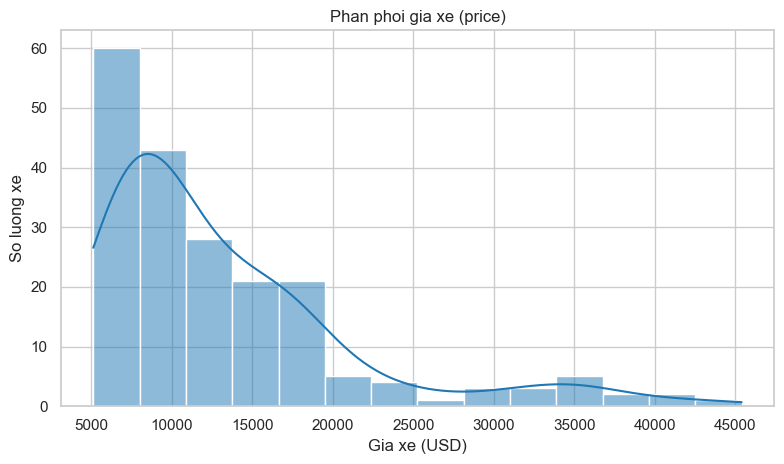

In [43]:
# TODO M2.1: histogram/KDE cua price
plt.figure()
sns.histplot(analysis_df["price"], kde=True, color="tab:blue")
plt.title("Phan phoi gia xe (price)")
plt.xlabel("Gia xe (USD)")
plt.ylabel("So luong xe")
plt.tight_layout()
plt.show()

**Nhận xét:** Phân phối giá bị lệch phải, phần lớn xe nằm ở mức giá thấp tới trung bình, một số ít xe sang có giá rất cao kéo dài cái đuôi về bên phải.

## M2.2 Dataset có cân bằng theo body style không?

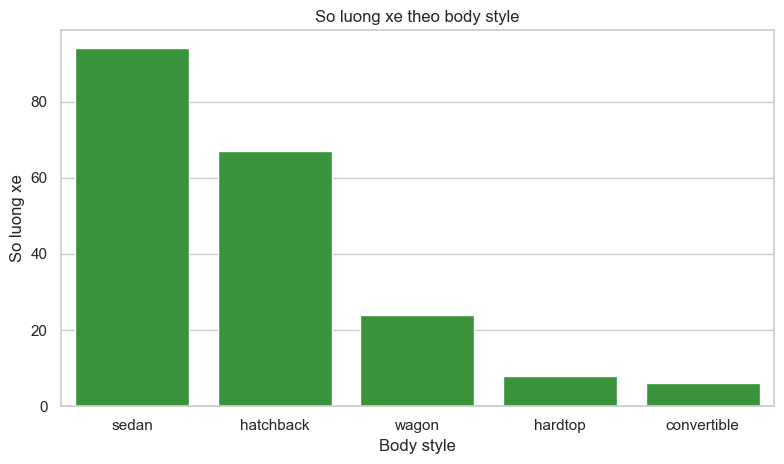

In [44]:
# TODO M2.2: countplot cua body_style
plt.figure()
body_order = analysis_df["body_style"].value_counts().index
sns.countplot(data=analysis_df, x="body_style", order=body_order, color="tab:green")
plt.title("So luong xe theo body style")
plt.xlabel("Body style")
plt.ylabel("So luong xe")
plt.tight_layout()
plt.show()

**Nhận xét:** Dataset không cân bằng, sedan và hatchback chiếm đa số, còn hardtop và convertible rất ít mẫu, nên mọi kết luận về hai nhóm hiếm này cần được nhìn một cách thận trọng.

## M2.3 Price khác nhau theo body style ra sao?

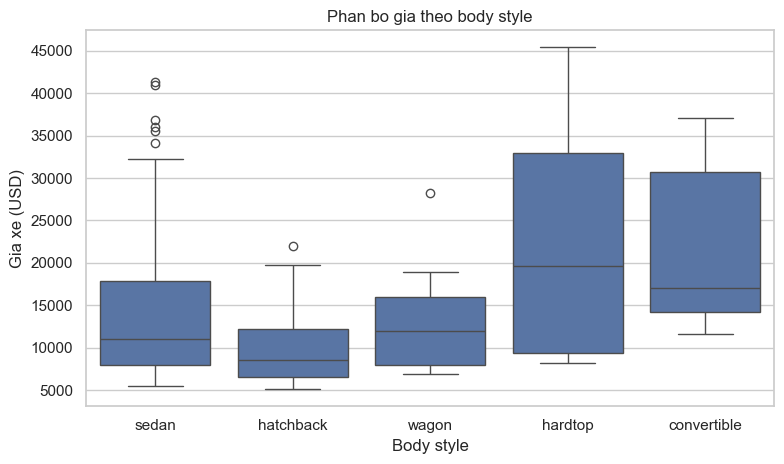

In [45]:
# TODO M2.3: boxplot price theo body_style
plt.figure()
body_order = analysis_df["body_style"].value_counts().index
sns.boxplot(data=analysis_df, x="body_style", y="price", order=body_order)
plt.title("Phan bo gia theo body style")
plt.xlabel("Body style")
plt.ylabel("Gia xe (USD)")
plt.tight_layout()
plt.show()

**Nhận xét:** Xe hardtop và convertible có giá trung vị cao nhất còn hatchback thường rẻ nhất, nhưng các hộp vẫn chồng lấn nhau khá nhiều nên body style chỉ giải thích được một phần chênh lệch giá.

## M2.4 Engine size liên quan thế nào tới price?

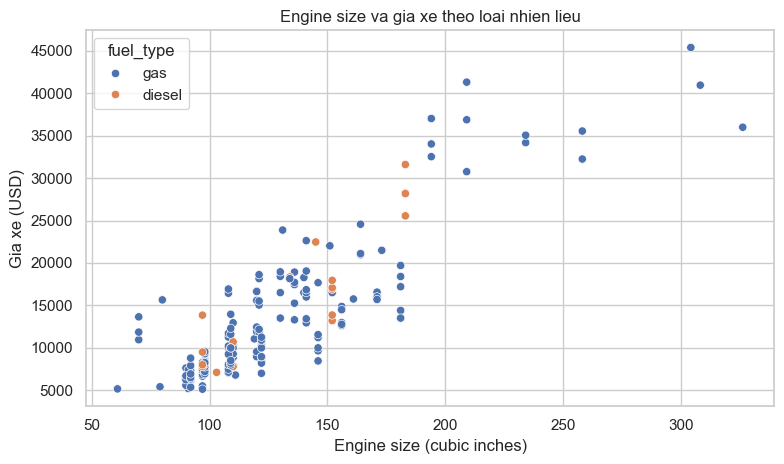

In [46]:
# TODO M2.4: scatterplot engine_size va price, hue=fuel_type
plt.figure()
sns.scatterplot(data=analysis_df, x="engine_size", y="price", hue="fuel_type")
plt.title("Engine size va gia xe theo loai nhien lieu")
plt.xlabel("Engine size (cubic inches)")
plt.ylabel("Gia xe (USD)")
plt.tight_layout()
plt.show()

**Nhận xét:** Engine size càng lớn thì giá xe có xu hướng càng cao, quan hệ đồng biến hiện lên khá rõ, xe chạy gas chiếm phần lớn còn xe diesel ít và nằm rải rác nên khó rút ra kết luận riêng cho nhóm diesel.

## M2.5 Các feature numeric tương quan ra sao?

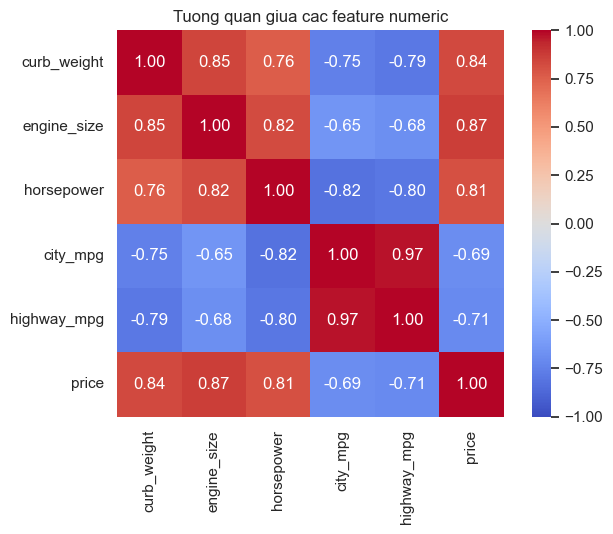

In [47]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(7, 5.5))
corr = analysis_df[AUTO_FEATURES].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", square=True)
plt.title("Tuong quan giua cac feature numeric")
plt.tight_layout()
plt.show()

**Nhận xét:** `curb_weight`, `engine_size` và `horsepower` tương quan dương mạnh với `price`, còn `city_mpg` và `highway_mpg` tương quan âm với `price`, nghĩa là xe càng nặng và càng mạnh thì thường càng đắt và càng tốn xăng.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

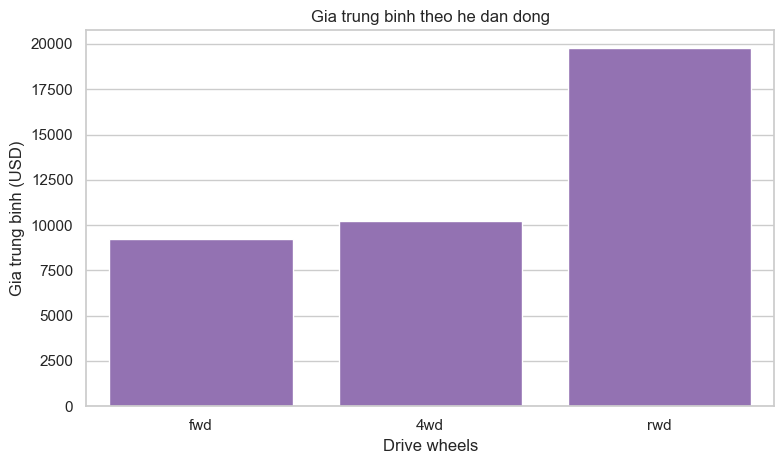

drive_wheels
fwd     9239.0
4wd    10241.0
rwd    19758.0
Name: price, dtype: float64


In [48]:
# TODO M2.6: bieu do tu chon
# Cau hoi: he dan dong nao gan voi gia xe cao hon?
plt.figure()
price_by_drive = analysis_df.groupby("drive_wheels")["price"].mean().sort_values()
sns.barplot(x=price_by_drive.index, y=price_by_drive.values, color="tab:purple")
plt.title("Gia trung binh theo he dan dong")
plt.xlabel("Drive wheels")
plt.ylabel("Gia trung binh (USD)")
plt.tight_layout()
plt.show()
print(price_by_drive.round(0))

**Nhận xét:** Xe dẫn động cầu sau rwd có giá trung bình cao hơn hẳn xe cầu trước fwd và xe 4wd, điều này hợp lý vì rwd hay xuất hiện ở các dòng xe thể thao và xe sang trong bộ dữ liệu.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

Qua quá trình khám phá bộ dữ liệu 1985 Automobile, em rút ra vài phát hiện chính. Thứ nhất, giá xe phân phối lệch phải, đa số xe ở mức giá thấp tới trung bình còn vài xe sang kéo giá lên rất cao, thể hiện qua histogram và qua 14 xe bị đánh dấu là outlier về giá. Thứ hai, `engine_size` tương quan dương mạnh với `price` với hệ số khoảng 0.87, xe có động cơ lớn thường đắt hơn. Thứ ba, `curb_weight` và `horsepower` cũng liên hệ chặt với giá, trong khi `city_mpg` và `highway_mpg` lại tương quan âm với giá, cho thấy xe càng mạnh và nặng thì càng tốn xăng. Thứ tư, dataset mất cân bằng theo body style, sedan và hatchback chiếm đa số còn hardtop và convertible rất ít.

Bộ dữ liệu cũng có vài hạn chế. Một là số mẫu nhỏ chỉ khoảng 200 xe và từ năm 1985 nên không phản ánh thị trường hiện nay. Hai là nhiều cột còn thiếu dữ liệu, đặc biệt `normalized_losses` thiếu tới 41 dòng nên khó dùng làm kết luận chính.

Cần nhớ rằng correlation không phải là causation, ví dụ xe tốn xăng thường đi kèm giá cao nhưng không có nghĩa là tốn xăng làm cho xe đắt, thực ra cả hai đều do động cơ lớn gây ra. Một câu hỏi em nghĩ nên phân tích tiếp là hãng xe `make` ảnh hưởng thế nào tới giá sau khi đã tính tới kích thước động cơ.